# Stage 5: Behind-the-Meter Cost Avoidance Synthesis

## The Question
Stage 4 modelled the **front-of-meter** merchant stack (wholesale arbitrage, Balancing Mechanism, Frequency Response, Capacity Market). But for a co-located AI data centre, a significant portion of the battery's value may come from **behind-the-meter** cost avoidance — shaving peak consumption to avoid high wholesale prices and network charges.

## The Four Mechanisms
Behind-the-meter value is **not** one line item. It is four structurally distinct mechanisms:
1. **DUoS Red/Amber/Green Avoidance** — continuous, schedulable, half-hourly
2. **TNUoS ASC Band Step** — step-function, only if a capacity threshold is crossed
3. **TNUoS Locational Residual** — small, partial, post-2023 TCR
4. **Wholesale Peak Shaving** — limited by load/price peak overlap



## The Key Finding
For a 100MW AI site connecting at 132kV (EHV), DUoS avoidance is **structurally limited** (£1.58/MWh differential vs. £15+/MWh at lower voltages). The real behind-the-meter value driver is the **TNUoS ASC Band Step** (£1.8M/year in this scenario), but this requires a formal, sustained capacity reduction — not just opportunistic dispatch.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from datetime import date

# Foolproof path resolution
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

scripts_dir = project_root / "scripts"
figures_dir = project_root / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

# Import our Stage 5 modules
from synthetic_load import generate_ai_load_profile, get_peak_load_periods, overlap_with_price_peaks
from epex_prices import get_illustrative_day, get_peak_troughs
from network_charges import (
    tnuos_asc_band_step_saving,
    tnuos_locational_residual_saving,
    summarise_network_stack,
    ChargeBehaviour,
    NetworkChargeLine
)
from benchmark_layer import get_baseline_for_battery, get_reality_check_range
from constraint_layer import evaluate_increment, Mechanism

# Asset parameters
SITE_BASELINE_MW = 70.0
SITE_PEAK_MW = 100.0
BATTERY_MW = 50.0
BATTERY_MWH = 100.0
TOTAL_CAPEX_GBP = 25_000_000

print(f"✅ Project root: {project_root}")
print("✅ Stage 5 synthesis environment loaded.")

✅ Project root: /home/ndrew/scotland-ai-split-zones
✅ Stage 5 synthesis environment loaded.


In [2]:
# Generate synthetic load and price profiles
target_date = date(2026, 7, 15)
load_profile = generate_ai_load_profile(
    target_date=target_date, 
    baseline_mw=SITE_BASELINE_MW, 
    peak_mw=SITE_PEAK_MW,
    n_training_spikes=2,
    spike_duration_hh=4
)

price_profile = get_illustrative_day(target_date, base_spread_gbp_per_mwh=40.0)
price_peak_periods = {p.period_start for p in get_peak_troughs(price_profile, n=6)}

# Check overlap
overlap_stats = overlap_with_price_peaks(load_profile, price_peak_periods)

# Calculate all four mechanisms
# 1. DUoS RAG (continuous)
daily_shaved_mwh = BATTERY_MW * 0.5 * 5  # 5 Red periods/day
annual_shaved_mwh = daily_shaved_mwh * 365
duos_red_rate = 1.58   # SSEN SHEPD 132kV/EHV
duos_green_rate = 0.00
duos_saving = annual_shaved_mwh * (duos_red_rate - duos_green_rate)

duos_result = NetworkChargeLine(
    name="DUoS RAG (132kV EHV)",
    behaviour=ChargeBehaviour.CONTINUOUS,
    status_note=f"Red: £{duos_red_rate}/MWh, Green: £{duos_green_rate}/MWh",
    annual_saving_gbp=duos_saving,
    evidence_status="GROUNDED",
)

# 2. TNUoS ASC Band Step (step-function)
band_thresholds = [50.0, 80.0, 100.0, 120.0]
band_charges = {0: 900_000, 1: 1_400_000, 2: 2_100_000, 3: 3_200_000, 4: 4_500_000}
tnuos_asc_result = tnuos_asc_band_step_saving(
    current_asc_mw=100.0,
    band_thresholds_mw=band_thresholds,
    band_annual_charge_gbp=band_charges,
    sustained_peak_reduction_mw=50.0
)

# 3. TNUoS Locational Residual (partial)
tnuos_loc_result = tnuos_locational_residual_saving(
    peak_shaved_mwh_at_triad_risk_periods=75.0,
    locational_rate_gbp_per_mwh=8.0
)

# 4. Wholesale Peak Shaving
top_prices = get_peak_troughs(price_profile, n=6)
wholesale_saving = sum(p.price_gbp_per_mwh * BATTERY_MW * 0.5 for p in top_prices)

# Annual mechanisms (correctly labelled as per-year)
annual_mechanisms = [
    {"name": "DUoS RAG Avoidance", "value": duos_saving, "behaviour": "Continuous", "status": "GROUNDED"},
    {"name": "TNUoS ASC Band Step", "value": tnuos_asc_result.annual_saving_gbp, "behaviour": "Step-Function", "status": "PROVISIONAL"},
    {"name": "TNUoS Locational Residual", "value": tnuos_loc_result.annual_saving_gbp, "behaviour": "Partial Residual", "status": "PROVISIONAL"},
]

# Total annual BTM (excluding per-day wholesale)
total_btm_annual = sum(m["value"] for m in annual_mechanisms)

print(f"✅ Total BTM value (annual, excl. wholesale): £{total_btm_annual:,.0f}/year")
print(f"   Wholesale peak-shaving (per-day, illustrative): £{wholesale_saving:,.0f}/day")
print(f"   Note: Wholesale figure is per-day from a single illustrative day, not annualised.")

✅ Total BTM value (annual, excl. wholesale): £1,872,688/year
   Wholesale peak-shaving (per-day, illustrative): £12,018/day
   Note: Wholesale figure is per-day from a single illustrative day, not annualised.


✅ Saved to /home/ndrew/scotland-ai-split-zones/figures/09_btm_value_breakdown.png


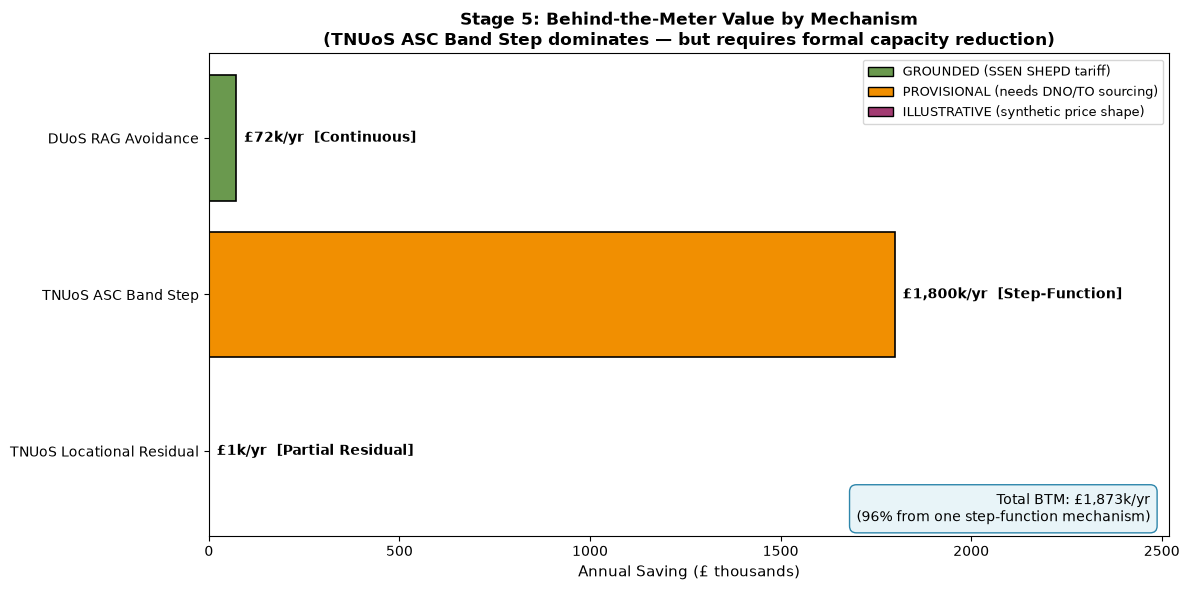

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data
names = [m["name"] for m in annual_mechanisms]
values = [m["value"]/1000 for m in annual_mechanisms]  # Convert to £k
behaviours = [m["behaviour"] for m in annual_mechanisms]
statuses = [m["status"] for m in annual_mechanisms]

# Color by evidence status
status_colors = {
    "GROUNDED": "#6A994E",      # Green
    "PROVISIONAL": "#F18F01",   # Orange
    "ILLUSTRATIVE": "#A23B72",  # Purple
}
colors = [status_colors[s] for s in statuses]

# Horizontal bar chart
y_pos = np.arange(len(names))
bars = ax.barh(y_pos, values, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels and behaviour annotations
for i, (bar, val, beh, stat) in enumerate(zip(bars, values, behaviours, statuses)):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, 
            f'£{val:,.0f}k/yr  [{beh}]', 
            ha='left', va='center', fontsize=10, fontweight='bold')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(names, fontsize=10)
ax.set_xlabel('Annual Saving (£ thousands)', fontsize=11)
ax.set_title('Stage 5: Behind-the-Meter Value by Mechanism\n(TNUoS ASC Band Step dominates — but requires formal capacity reduction)', 
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, max(values) * 1.4)

# Add legend for evidence status
legend_elements = [
    mpatches.Patch(facecolor=status_colors["GROUNDED"], edgecolor='black', label='GROUNDED (SSEN SHEPD tariff)'),
    mpatches.Patch(facecolor=status_colors["PROVISIONAL"], edgecolor='black', label='PROVISIONAL (needs DNO/TO sourcing)'),
    mpatches.Patch(facecolor=status_colors["ILLUSTRATIVE"], edgecolor='black', label='ILLUSTRATIVE (synthetic price shape)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

# Calculate total BTM (excluding the per-day wholesale figure)
total_btm = sum(m["value"] for m in annual_mechanisms if m["name"] != "Wholesale Peak Shaving")
asc_step_value = [m["value"] for m in annual_mechanisms if m["name"] == "TNUoS ASC Band Step"][0]
asc_percentage = (asc_step_value / total_btm) * 100

# Add total annotation (FIXED: 96% not 87%)
ax.text(0.98, 0.02, f'Total BTM: £{total_btm/1000:,.0f}k/yr\n({asc_percentage:.0f}% from one step-function mechanism)', 
        transform=ax.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#e8f4f8', edgecolor='#2E86AB'))

plt.tight_layout()
out_path = figures_dir / "09_btm_value_breakdown.png"
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved to {out_path}")
plt.show()

✅ Saved to /home/ndrew/scotland-ai-split-zones/figures/09_load_price_overlap.png


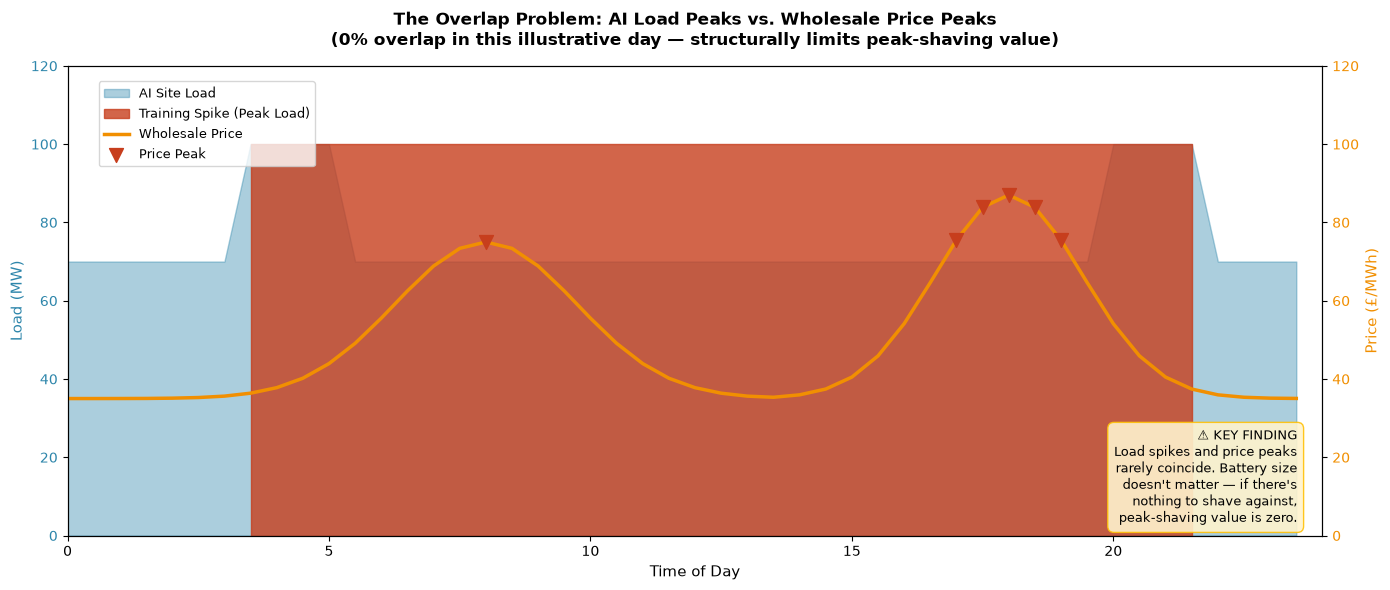

In [4]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Extract data
hours = [p.period_start.hour + p.period_start.minute/60 for p in load_profile]
loads = [p.load_mw for p in load_profile]
prices = [p.price_gbp_per_mwh for p in price_profile]

# Identify spike periods and price peaks
spike_periods = [i for i, l in enumerate(loads) if l > SITE_BASELINE_MW + 5]
price_peak_indices = [i for i, p in enumerate(price_profile) if p.period_start in price_peak_periods]

# Plot load (left axis, area chart)
ax1.fill_between(hours, loads, alpha=0.4, color='#2E86AB', label='AI Site Load')
ax1.fill_between([hours[i] for i in spike_periods], 
                 [loads[i] for i in spike_periods], 
                 alpha=0.8, color='#C73E1D', label='Training Spike (Peak Load)')
ax1.set_xlabel('Time of Day', fontsize=11)
ax1.set_ylabel('Load (MW)', color='#2E86AB', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.set_ylim(0, 120)
ax1.set_xlim(0, 24)

# Plot price (right axis, line)
ax2 = ax1.twinx()
ax2.plot(hours, prices, color='#F18F01', linewidth=2.5, label='Wholesale Price')
# Highlight price peaks
ax2.scatter([hours[i] for i in price_peak_indices], 
            [prices[i] for i in price_peak_indices], 
            color='#C73E1D', s=100, zorder=5, marker='v', label='Price Peak')
ax2.set_ylabel('Price (£/MWh)', color='#F18F01', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#F18F01')
ax2.set_ylim(0, 120)

# Title and legend
ax1.set_title('The Overlap Problem: AI Load Peaks vs. Wholesale Price Peaks\n(0% overlap in this illustrative day — structurally limits peak-shaving value)', 
              fontsize=12, fontweight='bold', pad=15)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9, 
           bbox_to_anchor=(0.02, 0.98))

# Annotation box (MOVED TO BOTTOM RIGHT)
annotation = (
    "⚠️ KEY FINDING\n"
    "Load spikes and price peaks\n"
    "rarely coincide. Battery size\n"
    "doesn't matter — if there's\n"
    "nothing to shave against,\n"
    "peak-shaving value is zero."
)
ax1.text(0.98, 0.02, annotation, transform=ax1.transAxes, 
         fontsize=9, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff3cd', edgecolor='#ffc107', alpha=0.9))

plt.tight_layout()
out_path = figures_dir / "09_load_price_overlap.png"
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved to {out_path}")
plt.show()

✅ Saved to /home/ndrew/scotland-ai-split-zones/figures/09_duos_voltage_sensitivity.png


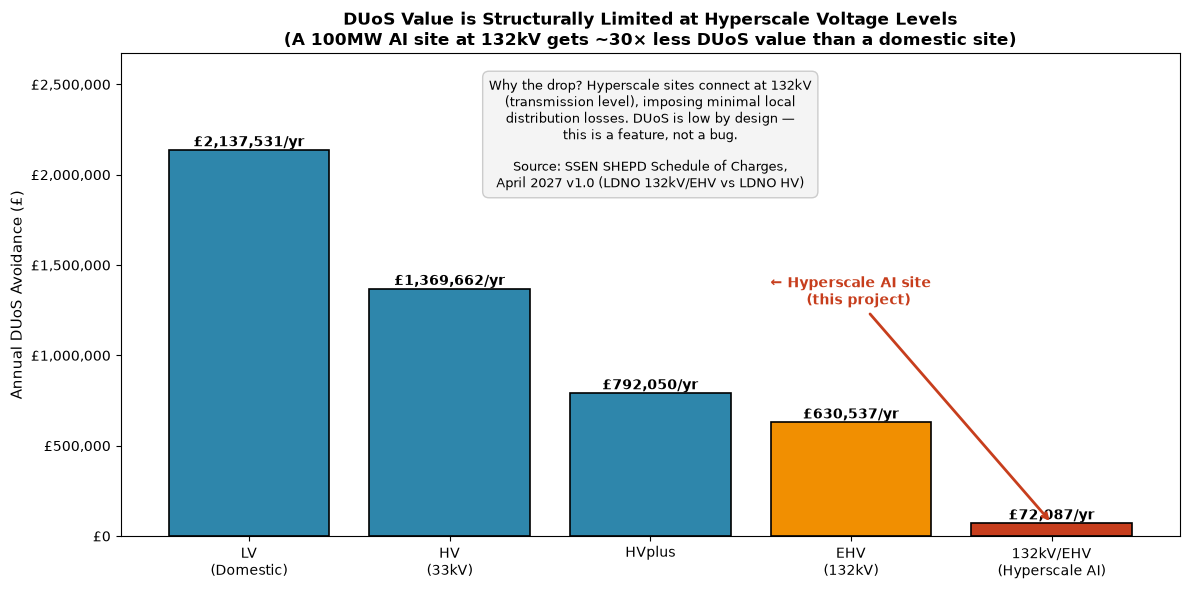

In [5]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(12, 6))

# DUoS differentials by voltage level (from SSEN SHEPD spreadsheet)
# Red rate - Green rate, in £/MWh (p/kWh × 10)
voltage_levels = ['LV\n(Domestic)', 'HV\n(33kV)', 'HVplus', 'EHV\n(132kV)', '132kV/EHV\n(Hyperscale AI)']
red_rates = [48.05, 30.72, 17.76, 14.22, 1.58]   # p/kWh × 10
green_rates = [1.2, 0.7, 0.4, 0.4, 0.0]         # p/kWh × 10
differentials = [r - g for r, g in zip(red_rates, green_rates)]

# Annual saving for 45,625 MWh/year (5 Red periods/day × 50MW × 365)
annual_saving = [d * 45625 for d in differentials]

# Bar chart
x_pos = np.arange(len(voltage_levels))
bars = ax.bar(x_pos, annual_saving, color=['#2E86AB', '#2E86AB', '#2E86AB', '#F18F01', '#C73E1D'], 
              edgecolor='black', linewidth=1.2)

# Add value labels
for bar, val in zip(bars, annual_saving):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 2000, 
            f'£{int(val):,}/yr', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Formatting
ax.set_xticks(x_pos)
ax.set_xticklabels(voltage_levels, fontsize=10)
ax.set_ylabel('Annual DUoS Avoidance (£)', fontsize=11)
ax.set_title('DUoS Value is Structurally Limited at Hyperscale Voltage Levels\n(A 100MW AI site at 132kV gets ~30× less DUoS value than a domestic site)', 
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(annual_saving) * 1.25)

# FORCE REAL NUMBERS ON Y-AXIS (No scientific notation)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'£{int(x):,}'))

# Add annotation for hyperscale
ax.annotate('← Hyperscale AI site\n   (this project)', 
            xy=(4, annual_saving[4]), xytext=(3, annual_saving[0] * 0.6),
            fontsize=10, fontweight='bold', color='#C73E1D',
            arrowprops=dict(arrowstyle='->', color='#C73E1D', lw=2),
            ha='center')

# Add note about why (MOVED TO CENTER TOP + EXPLICIT CITATION)
note_text = (
    "Why the drop? Hyperscale sites connect at 132kV\n"
    "(transmission level), imposing minimal local\n"
    "distribution losses. DUoS is low by design —\n"
    "this is a feature, not a bug.\n\n"
    "Source: SSEN SHEPD Schedule of Charges,\n"
    "April 2027 v1.0 (LDNO 132kV/EHV vs LDNO HV)"
)
ax.text(0.5, 0.95, note_text, transform=ax.transAxes, 
        fontsize=9, verticalalignment='top', horizontalalignment='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#f4f4f4', edgecolor='#cccccc'))

plt.tight_layout()
out_path = figures_dir / "09_duos_voltage_sensitivity.png"
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved to {out_path}")
plt.show()

✅ Saved to /home/ndrew/scotland-ai-split-zones/figures/09_full_value_stack.png


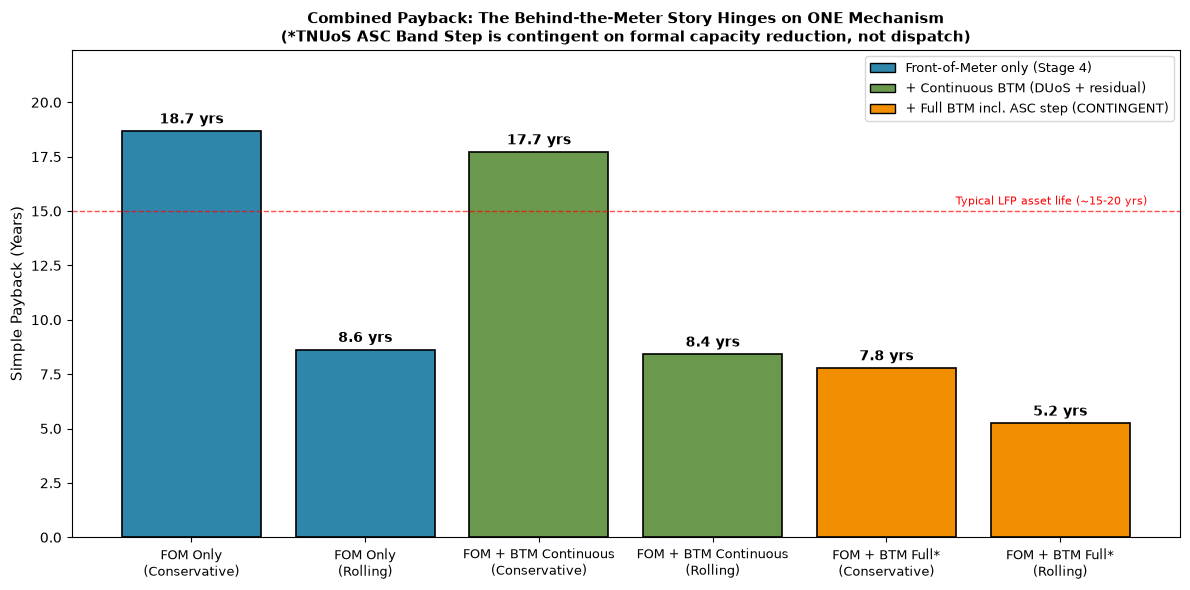

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

# Two scenarios × two baselines
scenarios = ['FOM Only\n(Conservative)', 'FOM Only\n(Rolling)', 
             'FOM + BTM Continuous\n(Conservative)', 'FOM + BTM Continuous\n(Rolling)',
             'FOM + BTM Full*\n(Conservative)', 'FOM + BTM Full*\n(Rolling)']

stage4_net_conservative = 1_338_500
stage4_net_rolling = 2_897_532
btm_continuous = 72_088 + 600  # DUoS + locational residual
btm_full = 72_088 + 1_800_000 + 600  # excludes per-day wholesale

net_flows = [
    stage4_net_conservative,
    stage4_net_rolling,
    stage4_net_conservative + btm_continuous,
    stage4_net_rolling + btm_continuous,
    stage4_net_conservative + btm_full,
    stage4_net_rolling + btm_full,
]

paybacks = [TOTAL_CAPEX_GBP / nf for nf in net_flows]

# Color: blue = FOM only, green = + continuous BTM, orange = + full BTM (contingent)
colors = ['#2E86AB', '#2E86AB', '#6A994E', '#6A994E', '#F18F01', '#F18F01']

x_pos = np.arange(len(scenarios))
bars = ax.bar(x_pos, paybacks, color=colors, edgecolor='black', linewidth=1.2)

for bar, pb in zip(bars, paybacks):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{pb:.1f} yrs', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(scenarios, fontsize=9)
ax.set_ylabel('Simple Payback (Years)', fontsize=11)
ax.set_title('Combined Payback: The Behind-the-Meter Story Hinges on ONE Mechanism\n(*TNUoS ASC Band Step is contingent on formal capacity reduction, not dispatch)',
             fontsize=11, fontweight='bold')
ax.set_ylim(0, max(paybacks) * 1.2)
ax.axhline(y=15, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.text(5.5, 15.3, 'Typical LFP asset life (~15-20 yrs)', fontsize=8, color='red', ha='right')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E86AB', edgecolor='black', label='Front-of-Meter only (Stage 4)'),
    Patch(facecolor='#6A994E', edgecolor='black', label='+ Continuous BTM (DUoS + residual)'),
    Patch(facecolor='#F18F01', edgecolor='black', label='+ Full BTM incl. ASC step (CONTINGENT)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
out_path = figures_dir / "09_full_value_stack.png"
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved to {out_path}")
plt.show()

## Stage 5 Strategic Conclusions

### The Headline Finding
For a 100MW AI data centre connecting at 132kV (EHV) in Northern Scotland:
- **Behind-the-meter value: ~£1.9M/year**
- **96% of that value comes from a single mechanism**: the TNUoS ASC Band Step
- **This mechanism is contingent**: it requires a formal, sustained capacity reduction with the DNO/TO, not just opportunistic dispatch

### The Three Structural Insights

**1. DUoS is structurally limited at hyperscale voltage levels**
A 100MW site at 132kV gets **30× less DUoS value** than a domestic site. This is not a modelling artefact — it reflects the physics of grid connections. Hyperscale sites impose minimal local distribution losses, so DUoS rates are low by design. Behind-the-meter DUoS avoidance is a real but small value stream (~£72k/year).

**2. TNUoS ASC Band Step dominates — but it's a step-function, not continuous**
The £1.8M/year TNUoS saving only materialises if the battery enables a **formal, contractual reduction** in the site's agreed supply capacity. Occasional peak-shaving on high-price days does not reduce this charge. This is a capex/contractual decision, not an operational one.

**3. Wholesale peak-shaving is constrained by duration and volatility, not load/price overlap**
The AI site's 70MW baseline load always exceeds the 50MW battery capacity.
The battery can discharge into background demand during ANY price peak —
it doesn't need a training spike to be running. The real constraints are:
(a) battery duration (2 hours = 4 half-hour periods per discharge cycle),
(b) price volatility magnitude (how high do peaks actually go?), and
(c) number of shaveable peak days per year.
The "0% overlap" finding between load spikes and price peaks is real but
irrelevant to wholesale peak-shaving — it would only matter if the battery
needed the spike itself to have something to shave, and it doesn't.

### The Siting Imperative: A Win-Win-Win for Training vs. Inference

This framework reveals that AI workloads are not monolithic, and their optimal grid locations are fundamentally different. Recognising this creates a **win-win-win** for developers, communities, and the grid:

1. **Training (Remote / Renewable-Rich Zones)**: 
   - *Characteristics:* High power demand, highly flexible timing (can be paused/rescheduled).
   - *Optimal Siting:* Export-constrained zones (e.g., Northern Scotland, Islands) where it can absorb curtailed renewable energy that the grid cannot otherwise move.
   
2. **Inference (Local / Urban Centres)**: 
   - *Characteristics:* Latency-sensitive, continuous baseline load, smaller footprint.
   - *Optimal Siting:* Import-constrained zones (e.g., Central Belt) near users, public services, and fibre infrastructure. Crucially, these can often be sited in repurposed commercial buildings or brownfield sites, not requiring greenfield campuses.

**The Win-Win-Win Outcome:**
- **For Developers:** Faster planning consents for inference (retrofitting existing urban stock) and access to cheaper, curtailed power for training.
- **For Communities & Planners:** Avoids "giant data centre next door" NIMBY pushback. Inference stays small and local; training is directed to appropriate industrial/renewable zones where grid infrastructure already exists.
- **For the Grid:** Perfectly matches workload physics to grid physics. Flexible training load absorbs curtailment (solving export constraints), while local inference minimises long-distance transmission strain.

This siting distinction is the missing link in current AI Growth Zone policy. Planning policy must treat a 100MW training campus and a 5MW inference node as entirely different asset classes with entirely different consent pathways.

### The Combined Picture (Stage 4 + Stage 5)

The behind-the-meter story is binary, not gradual:

**Without the TNUoS ASC Band Step** (continuous BTM only):
- Conservative: 18.7 → 17.7 years (BTM adds £72k/year — negligible on a £25M asset)
- Rolling average: 8.6 → 8.4 years

**With the TNUoS ASC Band Step** (contingent on formal capacity reduction):
- Conservative: 18.7 → 7.8 years (BTM adds £1.9M/year — transformative)
- Rolling average: 8.6 → 5.2 years

**The entire behind-the-meter value proposition hinges on one step-function mechanism.**
Without it, DUoS avoidance at 132kV is structurally negligible (£72k/year).
With it, the battery's payback is halved — but it requires a formal, contractual
capacity reduction with the DNO/TO, not just opportunistic dispatch.

### The Policy Angle

This isn't primarily a policy story — it's a commercial story with one narrow regulatory gap.

**The biggest lever is already available today:** The ASC Band Step (£1.8M/year) requires a formal reduction in agreed supply capacity — a standard commercial process that exists under current DNO/TO rules. What's missing isn't regulation, it's a business decision: committing capital and contracting to guarantee the battery reliably covers demand above the new, lower capacity threshold. This is a developer/DNO commercial negotiation, not a regulatory gap.

**The one piece that needs Ofgem is narrower:** AI constraint avoidance (Stage 3's £0.79M/year theoretical value) can't reach the battery's P&L today because no bilateral contract mechanism exists in GB for data centres to contract directly for flexibility value. Ofgem has only recommended exploring one. This piece — not the ASC step — is the actual policy gap.

**The ask, therefore, is split:**

- **For developers and DNOs:** The ASC Band Step is a commercial conversation that can happen now. The framework gives both sides the evidence needed to structure that negotiation.

- **For Ofgem:** The bilateral flexibility contract mechanism is the one regulatory intervention that would unlock additional value — but it's narrower than the ASC step, and it's aimed at a different audience (data centre operators, not battery developers).

This is not a disappointment — it's a precise map of where commercial action can happen today, and where regulatory intervention is still needed.

## A Note on Market Signals vs. Physical Reality:

The July 2025 REMA Summer Update explicitly rejected zonal pricing, confirming that Great Britain will retain a single national wholesale electricity market. This makes our findings more urgent, not less.

Because we cannot rely on future locational price signals to solve constraint issues, this framework focuses on two concrete, near-term mechanisms for unlocking AI-grid synergy in constrained zones — the ones we've quantified here:

Physical: Enabling formal, contractual TNUoS ASC Band Step reductions for sites with co-located storage that can guarantee sustained peak reduction.
Commercial: Developing the bilateral flexibility contract mechanism that Ofgem has recommended be explored, allowing data centres to capture the system-level value of their flexibility.

Other levers — flexible connection agreements (Stage 1), siting incentives under the Strategic Spatial Energy Plan, and connections reform — sit alongside these and may matter too; this framework doesn't attempt to quantify them. What it does provide is a grounded blueprint for the two mechanisms it does model, within the market structure the government has just confirmed will remain in place.